## Gráficos de Barra e de Área Empilhados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Nesta aula usaremos o Pandas para criar gráficos de barra e de área diretamente a partir de um dataframe.

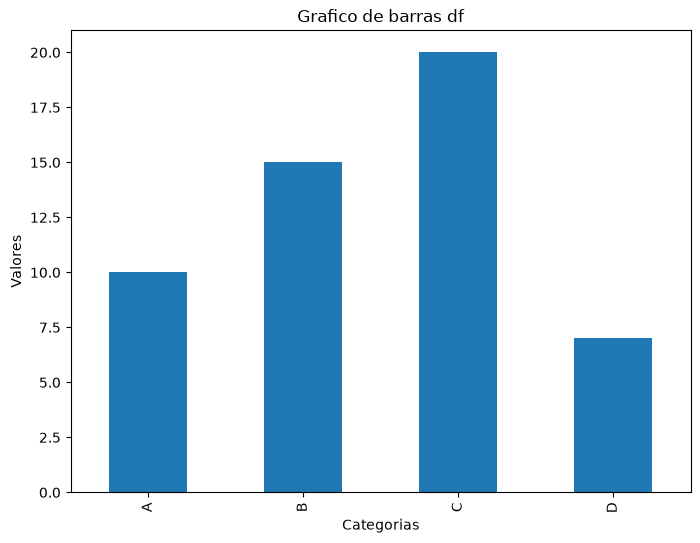

In [4]:
df = pd.DataFrame({'Categorias': ['A', 'B', 'C', 'D'], 
                   'Valores': [10, 15, 20, 7]})

plt.rcParams['figure.figsize'] = [8,6]
df.plot(kind= 'bar', x='Categorias', y= 'Valores', legend=False)
plt.xlabel('Categorias')
plt.ylabel('Valores')
plt.title('Grafico de barras df')
plt.show()


Agora, usaremos um dataset que exibe os dados sobre crimes na região de Washington DC. Veremos como agregar esses dados de modo a possibilitar gerar gráficos de barra e de área que ilustram a evolução de diferentes tipos de crime no decorrer dos anos.

Vamos começar criando o dataframe a partir de um arquivo csv.

In [5]:
df = pd.read_csv('washingtonDCCrime.csv')


In [8]:
df.head(30)

,Year,Crime,Rate
0,2005,Murder,33.5
1,2006,Murder,29.1
2,2007,Murder,30.8
3,2008,Murder,31.4
4,2009,Murder,24.2
5,2010,Murder,21.8
6,2011,Murder,17.4
7,2012,Murder,13.9
8,2013,Murder,15.9
9,2014,Murder,15.9


Usando a função crosstab do pacote pandas vamos agrupar os crimes por ano(Year) / tipo do crime (Crime). Note que Rate é a taxa de crimes por 100 mil habitantes.

In [11]:
summary = pd.crosstab(df['Year'], df['Crime'], values= df['Rate'], aggfunc= np.sum)
summary


Crime,Aggravated Assault,Murder,Rape,Robery
Year,,,,
2005,682.2,33.5,28.5,635.7
2006,789.1,29.1,31.8,658.4
2007,626.7,30.8,32.6,725.0
2008,626.4,31.4,31.4,748.5
2009,565.3,24.2,25.0,734.4
2010,559.1,21.8,30.9,715.0
2011,494.0,17.4,27.9,661.4
2012,553.3,13.9,37.3,637.3
2013,590.8,15.9,45.8,628.9


Vamos agora plotar um gráfico de barras a partir do sumário gerado.

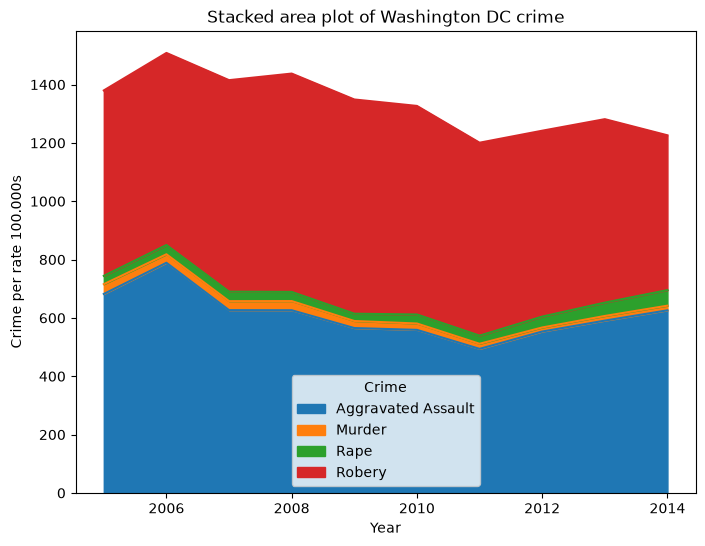

In [12]:
summary.plot(kind= 'area', stacked= True)
plt.title('Stacked area plot of Washington DC crime')
plt.ylabel('Crime per rate 100.000s')
plt.xlabel('Year')
plt.show()

É possível melhorar o aspecto do gráfico customizando o tamanho da fonte, a posição das legendas, etc. Para tanto é necessário usar set_context do pacote seaborn.

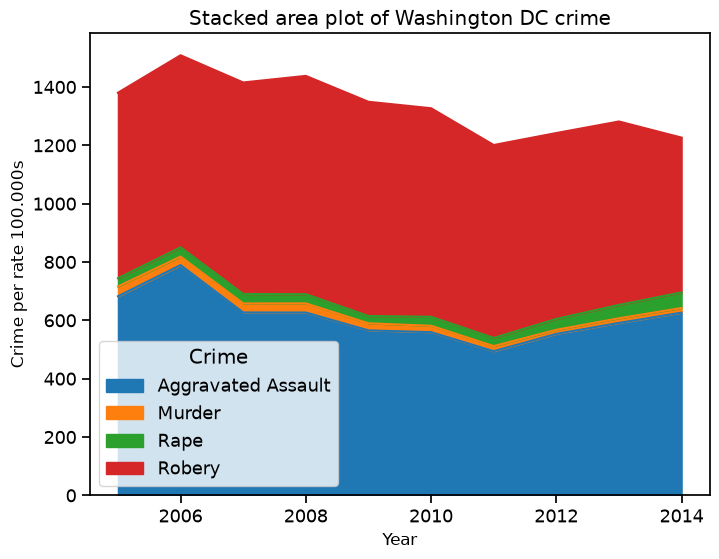

In [13]:
sns.set_context("notebook", font_scale=1.2, rc = {"font.size": 12, "axes.tittlesize": 16, "axes.labelsize": 12})
summary.plot(kind= 'area', stacked= True, )
plt.title('Stacked area plot of Washington DC crime')
plt.ylabel('Crime per rate 100.000s')
plt.xlabel('Year')
plt.show()

Por fim, para gerar um gráfico de barras, basta trocar 'area' por 'bar'.

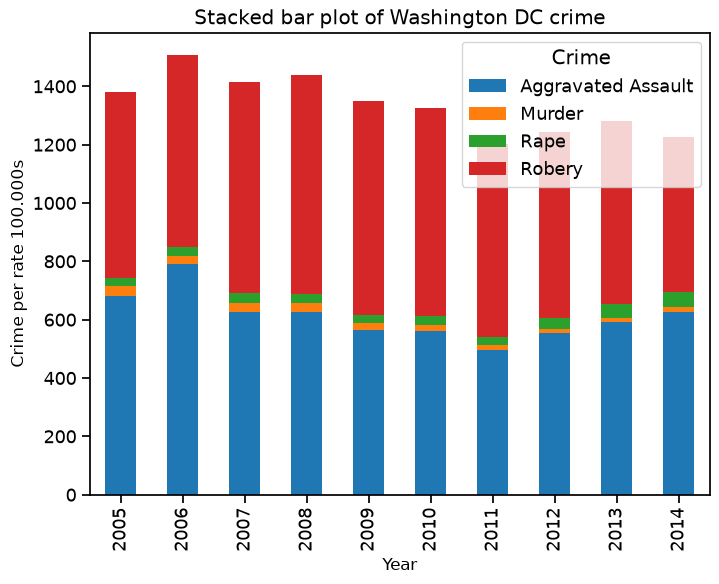

In [14]:
sns.set_context("notebook", font_scale=1.2, rc = {"font.size": 12, "axes.tittlesize": 16, "axes.labelsize": 12})
summary.plot(kind= 'bar', stacked= True, )
plt.title('Stacked bar plot of Washington DC crime')
plt.ylabel('Crime per rate 100.000s')
plt.xlabel('Year')
plt.show()

### Exercício 1
Neste exercício usaremos o dataset GDP_by_Country, que mostra o PIB de todos os países do globo entre os anos de 1999 e 2022.

In [19]:
dfGdp = pd.read_csv('GDP_by_Country.csv')
dfGdp.head()

,Country,1999,2000,2001,2002,2003,2004,2005,2006,2007,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,"Afghanistan, Rep. of.",0,0,0,4.084,4.585,5.971,7.309,8.399,9.892,...,21.555,24.304,0,0,0,0,0,0,0,0
1,Albania,3.444,3.695,4.096,4.456,5.6,7.452,8.376,9.133,10.163,...,14.91,16.053,11.591,12.204,13.214,14.341,15.553,16.996,16.77,18.012
2,Algeria,48.845,54.749,55.181,57.053,68.013,85.016,102.38,114.322,116.158,...,190.432,203.449,175.077,181.71,192.256,202.179,210.906,219.16,163.812,168.195
3,Angola,6.153,9.135,8.936,11.386,13.956,19.8,30.632,43.759,55.37,...,136.415,151.089,102.011,98.815,105.369,112.533,119.403,127.15,70.339,74.953
4,Antigua and Barbuda,0.652,0.678,0.71,0.718,0.754,0.818,0.875,0.962,1.026,...,1.404,1.494,1.285,1.328,1.386,1.458,1.536,1.617,1.405,1.534


Vamos fazer alguns ajustes no dataframe para facilitar sua manipulação:
1) Colocar o nome do país como índice
2) Ajustar os dados numéricos para float

In [ ]:
dfGdp.set_index('Country', inplace=True)
#ajuse no formato numerico para float
dfGdp = dfGdp.replace(',', '', regex=True)
dfGdp = dfGdp.astype(float)
#transforma os dados para float e retira as virgulas


Vamos agora selecionar apenas o PIB anual do Brasil.

In [21]:
dfBrasil = dfGdp.loc['Brazil']
dfBrasil.head()

1999    586.922
2000    644.283
2001    554.410
2002    505.712
2003    552.239
Name: Brazil, dtype: float64

Agora podemos plotar um gráfico de barras e observar a evolução do PIB do Brasil ao longo dos anos.

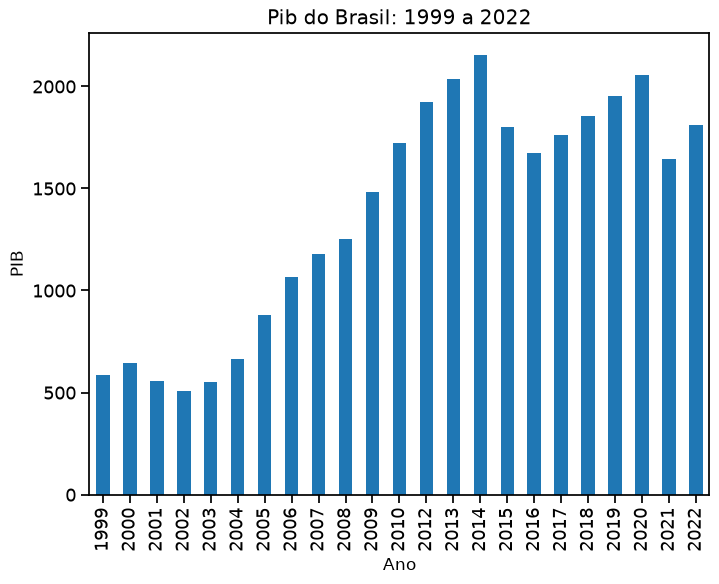

In [22]:
dfBrasil.plot(kind='bar')
plt.xlabel('Ano')
plt.ylabel('PIB')
plt.title('Pib do Brasil: 1999 a 2022')
plt.show()

### Exercício 2
Plote um gráfico que mostre os 15 países com maior PIB no ano de 2022.

In [35]:
df15 = dfGdp[['2022']]
df15Sorted = df15.sort_values(by='2022', ascending=False)
dfFinal = df15Sorted(15)
dfFinal.head(15)

TypeError: '<' not supported between instances of 'float' and 'str'

In [32]:
dfFinal.plot(kind='barh')
plt.ylabel('países')
plt.xlabel('PIB')
plt.title('15 maiores pibs em 2022')
plt.show()

NameError: name 'dfFinal' is not defined